## Data Governance & Data Quality

**Dataset :** Superstore Global Sales Data  
**Objectif :** Implémenter un système complet de Data Governance & Data Quality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\Users\hp\Documents\Mini_Project\data-governance-quality\data\dirty_superstore.csv', encoding='latin1')


In [3]:
print(f"Lignes    : {df.shape[0]}")
print(f"Colonnes  : {df.shape[1]}")
df.head()

Lignes    : 53854
Colonnes  : 24


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098.0,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,$221.98,2,0.0,$62.15,40.77,High
1,26341.0,IN-2014-JR162107-41675,NaN,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black","$3,709.40",9,0.1,$-288.77,923.63,Critical
2,25330.0,IN-2014-CR127307-41929,NaN,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID","$5,175.17",9,0.1,$919.97,915.49,Medium
3,13524.0,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",unknown,5,0.1,$-96.54,910.16,Medium
4,47221.0,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed","$2,832.96",8,0.0,$311.52,903.04,Critical


# Types de données

In [4]:
print(f"Types de données :")
print(df.dtypes)

Types de données :
Row ID            float64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
Postal Code       float64
City                  str
State                 str
Country               str
Region                str
Market                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales                 str
Quantity            int64
Discount          float64
Profit                str
Shipping Cost     float64
Order Priority        str
dtype: object


# Valeurs manquantes

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)

rapport = pd.DataFrame({
    'Manquantes': missing,
    'Pourcentage(%)': missing_pct
})
print(rapport)

             Manquantes  Pourcentage(%)
Row ID             5392           10.01
Order ID           5363            9.96
Order Date         4266            7.92
Ship Date          5380            9.99
Ship Mode          5389           10.01
Postal Code       43401           80.59


# Doublons

In [9]:
print(f"Doublons : {df.duplicated().sum()}")

Doublons : 1313


#  Valeurs "unknown"

In [10]:
for col in df.columns:
    unknown = (df[col] == 'unknown').sum()
    if unknown > 0:
        print(f"{col} : {unknown} valeurs 'unknown'")

Sales : 5385 valeurs 'unknown'


# Valeurs manquantes par colonne

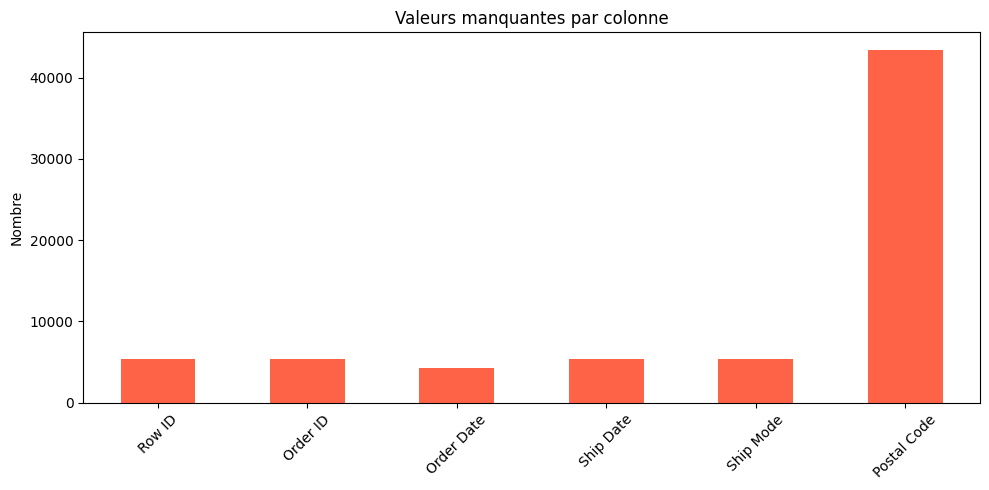

In [11]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='tomato')
plt.title('Valeurs manquantes par colonne')
plt.ylabel('Nombre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/missing_values.png')
plt.show()

# Distribution de Quantity

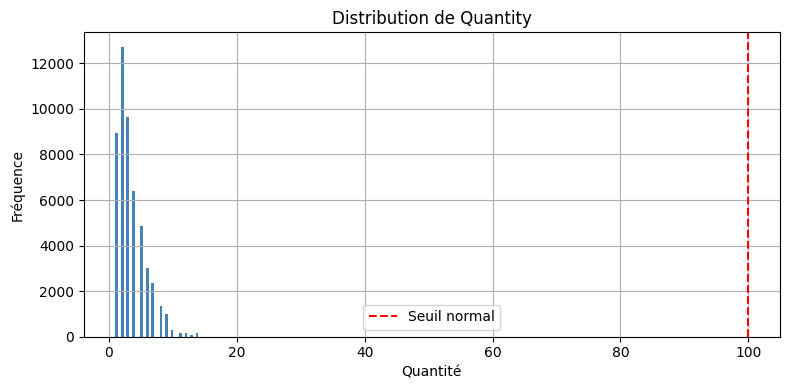

In [12]:
df_clean_qty = df[df['Quantity'] < 9999]

plt.figure(figsize=(8, 4))
df_clean_qty['Quantity'].hist(bins=30, color='steelblue')
plt.axvline(x=100, color='red', linestyle='--', label='Seuil normal')
plt.title('Distribution de Quantity')
plt.xlabel('Quantité')
plt.ylabel('Fréquence')
plt.legend()
plt.tight_layout()
plt.savefig('../images/outliers_quantity.png')
plt.show()

In [13]:
print(f"Quantité = 9999 : {(df['Quantity'] == 9999).sum()} lignes")

Quantité = 9999 : 2693 lignes


# Nettoyage des Données
### Correction 1 : Suppression des doublons

In [14]:
avant = len(df)
df = df.drop_duplicates()
après = len(df)

print(f"Avant  : {avant} lignes")
print(f"Après  : {après} lignes")
print(f"Supprimés : {avant - après} doublons")

Avant  : 53854 lignes
Après  : 52541 lignes
Supprimés : 1313 doublons


### Correction 2 : Valeurs manquantes

In [21]:
df['Ship Mode'] = df['Ship Mode'].fillna('Unknown')
df['Postal Code'] = df['Postal Code'].fillna(0)
df['Row ID'] = df['Row ID'].fillna(0)
df['Order ID'] = df['Order ID'].fillna('Unknown')
df = df.dropna(subset=['Order Date', 'Ship Date'])

print(f"Valeurs manquantes restantes : {df.isnull().sum().sum()}")
print(f"Lignes restantes : {len(df)}")

Valeurs manquantes restantes : 0
Lignes restantes : 52541


### Correction 3 : Valeurs "unknown" dans Sales

In [22]:
avant = len(df)
df = df[df['Sales'] != 'unknown']
après = len(df)

print(f"Avant  : {avant} lignes")
print(f"Après  : {après} lignes")
print(f"Supprimées : {avant - après} lignes unknown")

Avant  : 52541 lignes
Après  : 47167 lignes
Supprimées : 5374 lignes unknown


### Correction 4 : Format des colonnes

In [23]:
# Nettoyer Sales et Profit (enlever $ et ,)
df['Sales'] = df['Sales'].str.replace('$', '', regex=False)
df['Sales'] = df['Sales'].str.replace(',', '', regex=False)
df['Sales'] = pd.to_numeric(df['Sales'])

df['Profit'] = df['Profit'].str.replace('$', '', regex=False)
df['Profit'] = df['Profit'].str.replace(',', '', regex=False)
df['Profit'] = pd.to_numeric(df['Profit'])

# Corriger format dates
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

print(f"Sales  type : {df['Sales'].dtype}")
print(f"Profit type : {df['Profit'].dtype}")
print(f"Order Date  : {df['Order Date'].dtype}")
print(f"Ship Date   : {df['Ship Date'].dtype}")

Sales  type : float64
Profit type : float64
Order Date  : datetime64[us]
Ship Date   : datetime64[us]


### Correction 5 : Outliers Quantity = 9999

In [24]:
avant = len(df)
df = df[df['Quantity'] != 9999]
après = len(df)

print(f"Avant  : {avant} lignes")
print(f"Après  : {après} lignes")
print(f"Supprimés : {avant - après} outliers")

Avant  : 47167 lignes
Après  : 44763 lignes
Supprimés : 2404 outliers


### Correction 6 : Cohérence des dates

In [25]:
# Ship Date doit être >= Order Date
incoh = df[df['Ship Date'] < df['Order Date']]
print(f"Dates incohérentes : {len(incoh)} lignes")

# Supprimer les lignes incohérentes
df = df[df['Ship Date'] >= df['Order Date']]
print(f"Lignes restantes : {len(df)}")

Dates incohérentes : 3231 lignes
Lignes restantes : 32404


In [26]:
df.to_csv('../data/cleaned_superstore.csv', index=False)
print(f"Dataset nettoyé exporté")
print(f"Lignes finales : {len(df)}")

Dataset nettoyé exporté
Lignes finales : 32404


# Règles Data Quality

In [28]:
regles = {
    "Sales > 0"                        : (df['Sales'] > 0).all(),
    "Quantity entre 1 et 100"          : df['Quantity'].between(1, 100).all(),
    "Profit est un nombre"             : pd.api.types.is_float_dtype(df['Profit']),
    "Order Date est une date"          : pd.api.types.is_datetime64_any_dtype(df['Order Date']),
    "Ship Date >= Order Date"          : (df['Ship Date'] >= df['Order Date']).all(),
    "Customer Name non vide"           : df['Customer Name'].notna().all(),
    "Category non vide"                : df['Category'].notna().all(),
    "0 doublons"                       : df.duplicated().sum() == 0,
}

for regle, resultat in regles.items():
    statut = "Validée" if resultat else "Échouée"
    print(f"{statut} — {regle}")

Validée — Sales > 0
Validée — Quantity entre 1 et 100
Validée — Profit est un nombre
Validée — Order Date est une date
Validée — Ship Date >= Order Date
Validée — Customer Name non vide
Validée — Category non vide
Validée — 0 doublons


# Traçabilité

In [29]:
journal = [
    {'Date': '2026-05-08', 'Rôle': 'Data Steward', 'Action': 'Suppression doublons', 'Avant': '53854', 'Après': '52541'},
    {'Date': '2026-05-08', 'Rôle': 'Data Steward', 'Action': 'Suppression unknown Sales', 'Avant': '52541', 'Après': '47167'},
    {'Date': '2026-05-08', 'Rôle': 'Data Steward', 'Action': 'Correction format Sales/Profit', 'Avant': 'str', 'Après': 'float64'},
    {'Date': '2026-05-08', 'Rôle': 'Data Steward', 'Action': 'Correction format Dates', 'Avant': 'str', 'Après': 'datetime'},
    {'Date': '2026-05-08', 'Rôle': 'Data Steward', 'Action': 'Suppression outliers Quantity=9999', 'Avant': '47167', 'Après': '44763'},
    {'Date': '2026-05-08', 'Rôle': 'Data Steward', 'Action': 'Suppression dates incohérentes', 'Avant': '44763', 'Après': '32404'},
]

df_journal = pd.DataFrame(journal)
df_journal.to_csv('../reports/tracabilite.csv', index=False)
print(df_journal.to_string(index=False))

      Date         Rôle                             Action Avant    Après
2026-05-08 Data Steward               Suppression doublons 53854    52541
2026-05-08 Data Steward          Suppression unknown Sales 52541    47167
2026-05-08 Data Steward     Correction format Sales/Profit   str  float64
2026-05-08 Data Steward            Correction format Dates   str datetime
2026-05-08 Data Steward Suppression outliers Quantity=9999 47167    44763
2026-05-08 Data Steward     Suppression dates incohérentes 44763    32404


# Rôles Data Governance

In [30]:
roles = {
    'Rôle': ['Data Owner', 'Data Steward', 'Data Custodian', 'Data Consumer'],
    'Responsabilité': [
        'Responsable final des données',
        'Gère la qualité au quotidien',
        'Gère le stockage et sécurité',
        'Utilise les données'
    ],
    'Peut voir': ['✅', '✅', '✅', '✅'],
    'Peut modifier': ['✅', '✅', '❌', '❌'],
    'Peut supprimer': ['✅', '❌', '❌', '❌'],
    'Données sensibles': ['✅', '✅', '✅', '❌']
}

df_roles = pd.DataFrame(roles)
print(df_roles.to_string(index=False))

          Rôle                Responsabilité Peut voir Peut modifier Peut supprimer Données sensibles
    Data Owner Responsable final des données         ✅             ✅              ✅                 ✅
  Data Steward  Gère la qualité au quotidien         ✅             ✅              ❌                 ✅
Data Custodian  Gère le stockage et sécurité         ✅             ❌              ❌                 ✅
 Data Consumer           Utilise les données         ✅             ❌              ❌                 ❌


## Partie 4.1 : Catalogue des Règles Data Quality

In [2]:
import pandas as pd

In [5]:
catalogue = {
    'Règle': [
        'Sales > 0',
        'Quantity != 9999',
        'Ship Date >= Order Date',
        '0 doublons',
        'Format dates datetime',
        'Sales != unknown',
        'Profit est un nombre',
        'Customer Name non vide',
        'Category non vide',
        'Postal Code non vide'
    ],
    'Colonne': [
        'Sales', 'Quantity', 'Ship/Order Date',
        'Toutes', 'Order/Ship Date', 'Sales',
        'Profit', 'Customer Name', 'Category', 'Postal Code'
    ],
    'Type': [
        'Exactitude', 'Validité', 'Cohérence',
        'Unicité', 'Format', 'Exactitude',
        'Format', 'Complétude', 'Complétude', 'Complétude'
    ],
    'Priorité': [
        '🔴 Critique', '🔴 Critique', '🔴 Critique',
        '🟠 Haute', '🟠 Haute', '🟠 Haute',
        '🟠 Haute', '🟡 Moyenne', '🟡 Moyenne', '🟡 Moyenne'
    ],
    'Statut': [
        '✅ Validée', '✅ Validée', '✅ Validée',
        '✅ Validée', '✅ Validée', '✅ Validée',
        '✅ Validée', '✅ Validée', '✅ Validée', '✅ Validée'
    ]
}

df_catalogue = pd.DataFrame(catalogue)
df_catalogue.to_csv('../reports/catalogue_regles.csv', index=False)
print(df_catalogue.to_string(index=False))

                  Règle         Colonne       Type   Priorité    Statut
              Sales > 0           Sales Exactitude 🔴 Critique ✅ Validée
       Quantity != 9999        Quantity   Validité 🔴 Critique ✅ Validée
Ship Date >= Order Date Ship/Order Date  Cohérence 🔴 Critique ✅ Validée
             0 doublons          Toutes    Unicité    🟠 Haute ✅ Validée
  Format dates datetime Order/Ship Date     Format    🟠 Haute ✅ Validée
       Sales != unknown           Sales Exactitude    🟠 Haute ✅ Validée
   Profit est un nombre          Profit     Format    🟠 Haute ✅ Validée
 Customer Name non vide   Customer Name Complétude  🟡 Moyenne ✅ Validée
      Category non vide        Category Complétude  🟡 Moyenne ✅ Validée
   Postal Code non vide     Postal Code Complétude  🟡 Moyenne ✅ Validée
